# Figure 2

/tmp/ipykernel_3861732/1558815861.py:32: RuntimeWarning: invalid value encountered in log10
  im_psf = ax[0].imshow(np.log10(kernel_psf_class), cmap='cubehelix', origin='lower', vmin=-2, vmax=-9.9)


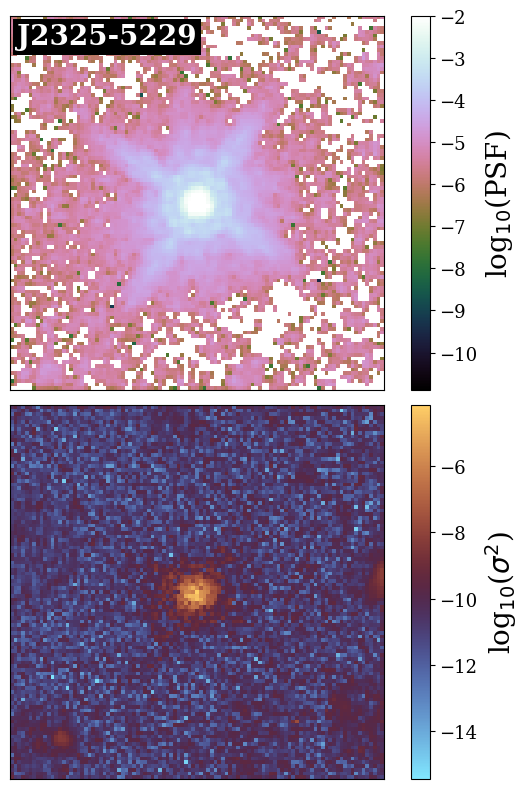

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import kernel_util

filt = 'F160W'
name = "J2325-5229"

fig, ax = plt.subplots(2, 1, figsize=(6, 8))  # 2 rows, 1 column
fontsize = 20

# Load PSF
psf_file = f'../../cutout_data/{name}/{filt}/outputs/full_PSF.fits'
kernel = pyfits.getdata(psf_file)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 301

kernel_cut = kernel_util.cut_psf(kernel, kernel_size)
kwargs_psf3 = {'psf_type': psf_type, 'kernel_point_source': kernel_cut, 
              'point_source_supersampling_factor': 3, 
              }

psf_class = PSF(**kwargs_psf3)
kernel_psf_class = psf_class.kernel_point_source

# Load variance map
error_map = np.loadtxt(f'../../cutout_data/{name}/{filt}/psf_variance.txt')
var_array = np.array(error_map)

# Top: PSF
im_psf = ax[0].imshow(np.log10(kernel_psf_class), cmap='cubehelix', origin='lower', vmin=-2, vmax=-9.9)
cbar_psf = fig.colorbar(im_psf, ax=ax[0])
cbar_psf.set_label(r'log$_{10}$(PSF)', fontsize=fontsize)
cbar_psf.ax.tick_params(labelsize=13)

# Bottom: PSF variance
im_var = ax[1].imshow(np.log10(var_array), cmap='managua_r', origin='lower')
cbar_var = fig.colorbar(im_var, ax=ax[1])
cbar_var.set_label(r'log$_{10}$($\sigma^2$)', fontsize=fontsize)
cbar_var.ax.tick_params(labelsize=13)

# Remove ticks
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

# Label system name on PSF panel
ax[0].text(
    0.02, 0.98, name,
    transform=ax[0].transAxes,
    fontsize=fontsize,
    color='white',
    fontweight='bold',
    va='top',
    ha='left',
    bbox=dict(facecolor='black', alpha=1.0, edgecolor='none', pad=3)
)

plt.tight_layout()
plt.savefig('psf_ir.png')
plt.show()


# Figure 3

/tmp/ipykernel_3861732/602178138.py:25: RuntimeWarning: invalid value encountered in log10
  np.log10(psf_init),
/tmp/ipykernel_3861732/602178138.py:35: RuntimeWarning: invalid value encountered in log10
  np.log10(psf_final),


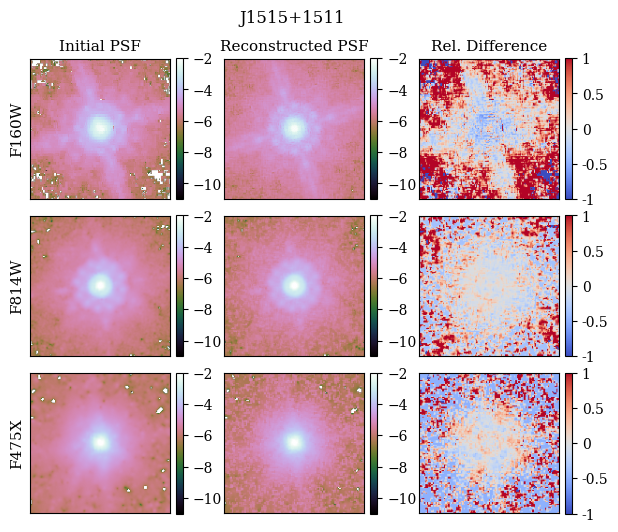

In [ ]:
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
import pickle

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'LikelihoodAddition':
            class LikelihoodAddition:
                pass
            return LikelihoodAddition
        return super().find_class(module, name)

mpl.rcParams['font.family'] = 'serif'

band_names = ["F160W", "F814W", "F475X"]

name = "J1515+1511"
# load joint MCMC
joint_file = f'../../joint_modeling/{name}/{name}_joint.pkl'
with open(joint_file, "rb") as f:
    loaded_data = CustomUnpickler(f).load()
    
fig, ax = plt.subplots(3, 3, figsize=(7, 7))

for i, band in enumerate(band_names):

    kwargs_psf = loaded_data["kwargs_data_joint"]["multi_band_list"][i][1]

    psf_init = kwargs_psf["kernel_point_source_init"]
    psf_final = kwargs_psf["kernel_point_source"]

    # Initial PSF
    im0 = ax[i, 0].imshow(
        np.log10(psf_init),
        origin="lower",
        cmap="cubehelix",
        vmin=-2,
        vmax=-10,
    )
    fig.colorbar(im0, ax=ax[i, 0], fraction=0.046, pad=0.04)

    # Reconstructed PSF
    im1 = ax[i, 1].imshow(
        np.log10(psf_final),
        origin="lower",
        cmap="cubehelix",
        vmin=-2,
        vmax=-10,
    )
    fig.colorbar(im1, ax=ax[i, 1], fraction=0.046, pad=0.04)

    # Difference
    im2 = ax[i, 2].imshow(
        (psf_final - psf_init) / psf_init,
        origin="lower",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
    )
    cbar = fig.colorbar(im2, ax=ax[i, 2], fraction=0.046, pad=0.04)
    cbar.formatter = FormatStrFormatter('%g')
    cbar.update_ticks()
    # Row labels
    ax[i, 0].set_ylabel(band, fontsize=11)

    # Remove ticks
    for j in range(3):
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        
    ny, nx = psf_init.shape
    
    zoom = 0.5 
    x_half = nx * zoom / 2
    y_half = ny * zoom / 2
    
    xc = (nx - 1) / 2
    yc = (ny - 1) / 2
    
    for j in range(3):
        ax[i, j].set_xlim(xc - x_half, xc + x_half)
        ax[i, j].set_ylim(yc - y_half, yc + y_half)

# Column titles
ax[0, 0].set_title("Initial PSF", fontsize=11)
ax[0, 1].set_title("Reconstructed PSF", fontsize=11)
ax[0, 2].set_title("Rel. Difference", fontsize=11)

#plt.tight_layout()
fig.subplots_adjust(hspace=-0.3)
fig.subplots_adjust(wspace=0.27)
fig.suptitle(f"{name}", x=0.5, y=0.89)
plt.savefig(f"{name}_psf_iter.png")
plt.show()
